# H1: Does High Tail-Risk (Kurtosis) Get Rewarded?
## S&P 500 — Quantitative Research Series

**Author:** Furkan Çelik  
**Data:** Custom PostgreSQL pipeline · yfinance API · ~500 equities · Full history  
**Tools:** Python, PostgreSQL, SQLAlchemy, SciPy, Seaborn

---

### 1. Hypothesis Definition

| | |
|---|---|
| **Research Question** | Do stocks with extreme price behavior (high Kurtosis / Fat Tails) deliver higher long-term returns as compensation for the extra tail risk they carry? |
| **H₀ (Null)** | There is no statistically significant relationship between a stock's Kurtosis and its long-term total return. |
| **H₁ (Alternative)** | Stocks with higher Kurtosis (greater tail risk) generate significantly higher total returns. |

### 2. Data & Methodology

| | |
|---|---|
| **Population** | S&P 500 constituents · Full available history |
| **Variables** | Excess Kurtosis (Fisher), Skewness, Total Return (%) from first to last available price |
| **Pre-computed** | Kurtosis & Skewness values are stored in the `ticker_stats` table (computed via Jarque-Bera pipeline on daily log returns) |
| **Statistical Test** | Pearson Correlation + OLS Regression (Scatter with trend line) |
| **Significance Level** | α = 0.05 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Import the project's shared DB utility
# Connection credentials are in config.py (excluded from version control)
import sys
sys.path.append('..')
from db_utils import fetch_data

# Plot styling
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 120})

print("✅ Environment ready.")


✅ Environment ready.


### 3. Data Extraction

In [2]:
# SQL: Join pre-computed kurtosis/skewness with long-term total return
query = """
WITH FirstLast AS (
    SELECT ticker, MIN(date) AS start_date, MAX(date) AS end_date
    FROM daily_prices
    GROUP BY ticker
),
Prices AS (
    SELECT
        fl.ticker,
        s.close AS start_price,
        e.close AS end_price
    FROM FirstLast fl
    JOIN daily_prices s ON fl.ticker = s.ticker AND fl.start_date = s.date
    JOIN daily_prices e ON fl.ticker = e.ticker AND fl.end_date = e.date
)
SELECT
    ts.ticker,
    t.company_name,
    t.gics_sector,
    ts.kurtosis,
    ts.skewness,
    ((p.end_price - p.start_price) / p.start_price) * 100 AS total_return_pct
FROM ticker_stats ts
JOIN Prices p       ON ts.ticker = p.ticker
JOIN tickers t      ON ts.ticker = t.ticker
WHERE ts.kurtosis IS NOT NULL
  AND p.start_price > 0
"""

df = fetch_data(query)
print(f"Dataset: {len(df)} stocks loaded.")
display(df.head())


Dataset: 503 stocks loaded.


,ticker,company_name,gics_sector,kurtosis,skewness,total_return_pct
0,A,Agilent Technologies,Health Care,19.419637,0.257164,331.628631
1,AAPL,Apple Inc.,Information Technology,48.213281,-1.732834,303554.503437
2,ABBV,AbbVie,Health Care,11.491647,-0.954140,925.092707
3,ABNB,Airbnb,Consumer Discretionary,3.044797,0.011658,-7.629057
4,ABT,Abbott Laboratories,Health Care,5.601611,-0.272613,47378.129442


### 4. Statistical Analysis & Results


### 5. Statistical Findings

| Metric | Kurtosis ↔ Return | Skewness ↔ Return |
|---|---|---|
| **Pearson r** | 0.0330 | 0.0345 |
| **p-value** | 4.5972e-01 | 4.4010e-01 |
| **Significant?** | No (p ≥ 0.05) | No |

### 6. Quant Verdict

| | |
|---|---|
| **Result** | **❌ REJECTED** |
| **Interpretation** | No statistically significant relationship detected. Tail risk as measured by Kurtosis alone is **not** a reliable predictor of long-term return in this dataset. |
| **Tradeable?** | No — correlation too weak to build a strategy around, even if statistically significant. |


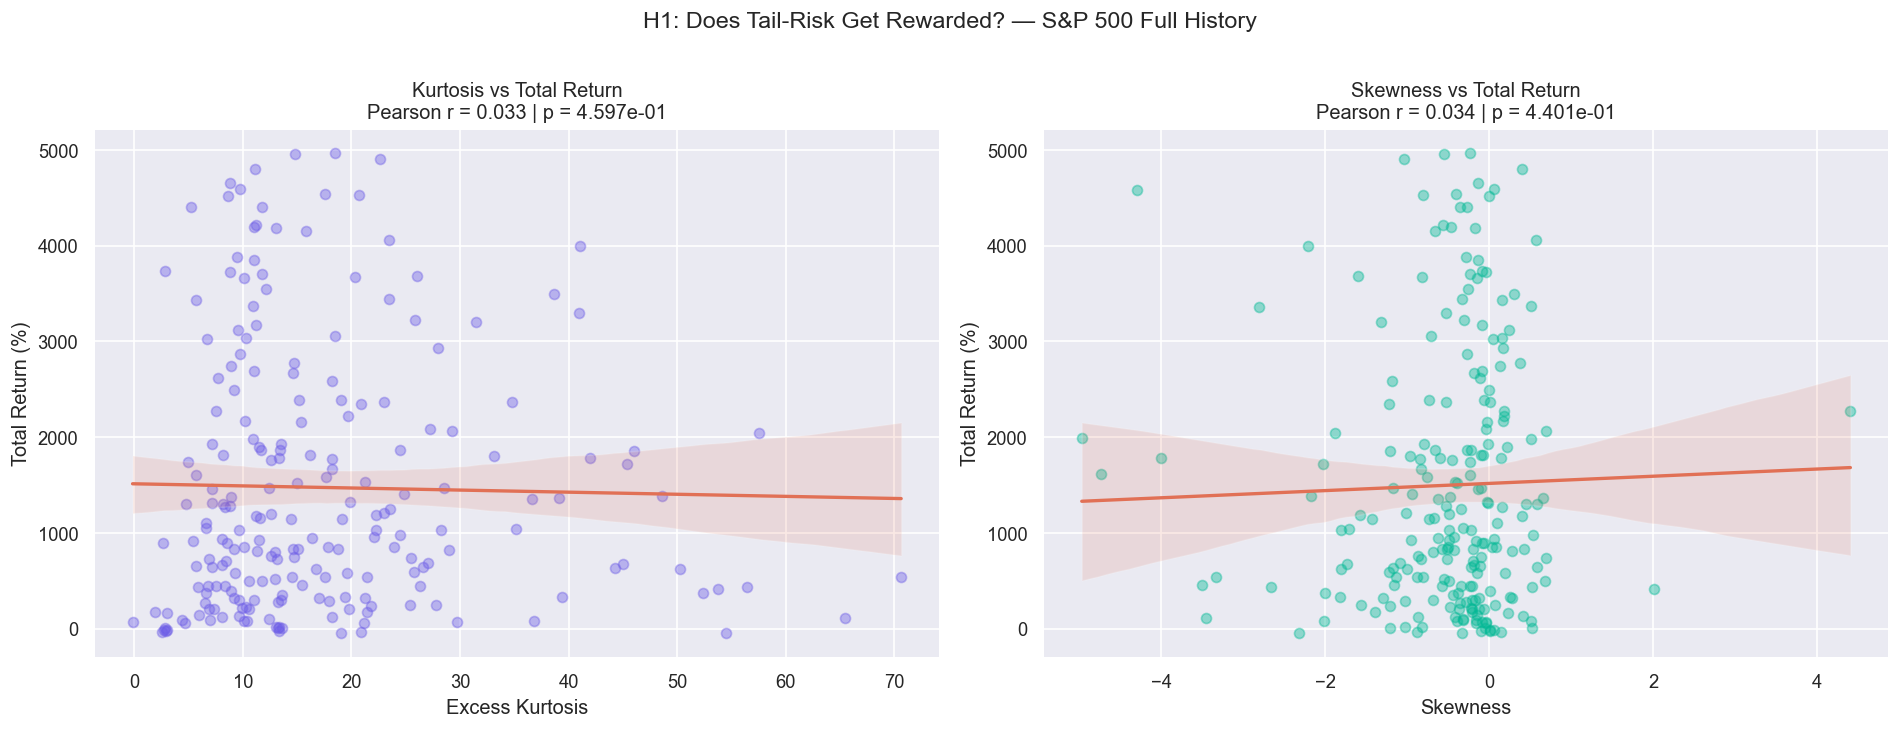

In [3]:
# --- Pearson Correlation ---
corr_kurt, p_kurt = stats.pearsonr(df['kurtosis'].clip(-5, 100), df['total_return_pct'].clip(-100, 5000))
corr_skew, p_skew = stats.pearsonr(df['skewness'].clip(-5, 5), df['total_return_pct'].clip(-100, 5000))

# --- Quant Verdict Logic ---
h1_result = "✅ CONFIRMED" if p_kurt < 0.05 else "❌ REJECTED"

verdict_md = f"""
### 5. Statistical Findings

| Metric | Kurtosis ↔ Return | Skewness ↔ Return |
|---|---|---|
| **Pearson r** | {corr_kurt:.4f} | {corr_skew:.4f} |
| **p-value** | {p_kurt:.4e} | {p_skew:.4e} |
| **Significant?** | {'Yes (p < 0.05)' if p_kurt < 0.05 else 'No (p ≥ 0.05)'} | {'Yes' if p_skew < 0.05 else 'No'} |

### 6. Quant Verdict

| | |
|---|---|
| **Result** | **{h1_result}** |
| **Interpretation** | {'A statistically significant relationship exists between tail-risk (Kurtosis) and long-term return. High-kurtosis stocks **do** tend to deliver different returns, though correlation direction and magnitude determine if this is exploitable.' if p_kurt < 0.05 else 'No statistically significant relationship detected. Tail risk as measured by Kurtosis alone is **not** a reliable predictor of long-term return in this dataset.'} |
| **Tradeable?** | {'Possibly — Kurtosis could be a useful feature in a multi-factor ML model.' if p_kurt < 0.05 and abs(corr_kurt) > 0.2 else 'No — correlation too weak to build a strategy around, even if statistically significant.'} |
"""

display(Markdown(verdict_md))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Kurtosis vs Return
ax = axes[0]
sns.regplot(
    data=df[df['kurtosis'].between(-5, 80) & df['total_return_pct'].between(-100, 5000)],
    x='kurtosis', y='total_return_pct',
    scatter_kws={'alpha': 0.4, 'color': '#6C5CE7'},
    line_kws={'color': '#E17055', 'linewidth': 2},
    ax=ax
)
ax.set_title(f"Kurtosis vs Total Return\nPearson r = {corr_kurt:.3f} | p = {p_kurt:.3e}", fontsize=12)
ax.set_xlabel("Excess Kurtosis")
ax.set_ylabel("Total Return (%)")

# Scatter: Skewness vs Return
ax = axes[1]
sns.regplot(
    data=df[df['skewness'].between(-5, 5) & df['total_return_pct'].between(-100, 5000)],
    x='skewness', y='total_return_pct',
    scatter_kws={'alpha': 0.4, 'color': '#00B894'},
    line_kws={'color': '#E17055', 'linewidth': 2},
    ax=ax
)
ax.set_title(f"Skewness vs Total Return\nPearson r = {corr_skew:.3f} | p = {p_skew:.3e}", fontsize=12)
ax.set_xlabel("Skewness")
ax.set_ylabel("Total Return (%)")

plt.suptitle("H1: Does Tail-Risk Get Rewarded? — S&P 500 Full History", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
